# 05b — Modelos Alternativos e Baselines

**Conteúdos Mínimos atendidos:** CM 4.2 (estratégia de validação + baseline) e CM 4.3 (dois modelos distintos documentados).

Este notebook compara cinco abordagens em três famílias algorítmicas distintas:

| Nível | Abordagem | Família |
|---|---|---|
| 1 | Baseline naive — sempre prever 0 | trivial |
| 2 | Baseline regra de negócio — n_criticos_30m ≥ N | heurística |
| 3 | Logistic Regression L1 | linear |
| 4 | Random Forest | bagging (ensemble) |
| 5 | LightGBM | boosting (ensemble) |

**Estratégia de validação:** split temporal estrito — Treino Jan-Abr/2025, Validação Mai/2025 (otimização de threshold), Teste Jun/2025 (avaliação final). Nenhum modelo viu Jun/2025 durante treino.

**Pipeline reproduzível:** `uv run python src/sprint1_compare_models.py` gera todas as métricas e figuras desta análise.

In [1]:
import json
from pathlib import Path
import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd().parent
results_file = ROOT / 'outputs' / 'gold' / 'comparison_sprint1.json'
figures_dir = ROOT / 'outputs' / 'figures'

payload = json.loads(results_file.read_text())
comp = pd.DataFrame(payload['comparison_table'])
print(f"Treino: {payload['train_months']} | Val: {payload['val_month']} | Teste: {payload['test_month']}")
print(f"Features: {payload['n_features']} | Threshold ótimo da regra de negócio: n_criticos_30m >= {payload['best_rule_threshold']}")

Treino: ['abr', 'feb', 'jan', 'mar'] | Val: ['may'] | Teste: ['jun']
Features: 60 | Threshold ótimo da regra de negócio: n_criticos_30m >= 3


## Tabela Comparativa — Métricas no Teste (Jun/2025)

In [2]:
display(comp.style.format({'F1': '{:.4f}', 'Precision': '{:.4f}', 'Recall': '{:.4f}', 'ROC-AUC': '{:.4f}', 'PR-AUC': '{:.4f}'})
        .highlight_max(subset=['F1', 'Precision', 'Recall', 'PR-AUC'], color='#A7F3D0')
        .set_caption('Comparação de modelos — ordenado por F1-Score'))

,Modelo,F1,Precision,Recall,ROC-AUC,PR-AUC
0,random_forest,0.6761,0.7229,0.6350,0.9938,0.7139
1,lightgbm,0.6728,0.7005,0.6472,0.9923,0.6739
2,rule_nn_criticos_30m_ge_3,0.1528,0.0967,0.3637,0.7127,0.2788
3,logistic_l1,0.1487,0.0854,0.5751,0.9670,0.0753
4,majority_class,0.0000,0.0000,0.0000,nan,nan


## Análise dos Resultados

### 1. Baseline naive (majority class)
F1 = **0.0000** com accuracy ~99,55%. Demonstra o severo desbalanceamento de classes (0,45% de positivos) e a inutilidade de accuracy como métrica para este problema. **Piso de comparação.**

### 2. Baseline regra de negócio (n_criticos_30m ≥ 3)
F1 = **0.1528** | Precision = 0.097 | Recall = 0.364. Representa a heurística operacional tradicional usada antes do ML. Captura ~36% dos eventos mas com altíssima taxa de falsos alarmes (apenas 10% das predições positivas são reais). **Justifica o investimento em modelos preditivos.**

### 3. Logistic Regression L1 (família linear)
F1 = **0.1487** | ROC-AUC = 0.967. Surpreendente: a regressão logística tem ROC-AUC excelente (separabilidade alta), mas PR-AUC baixíssimo (0.075). O modelo linear consegue ranquear os eventos corretamente em média, mas falha em separar com precisão no extremo de alto risco — onde decisões operacionais precisam ocorrer. **Confirma a não-linearidade do problema.**

### 4. Random Forest (família bagging)
F1 = **0.6761** | Precision = 0.723 | Recall = 0.635 | PR-AUC = 0.714. **Modelo vencedor desta comparação.** Captura interações não-lineares entre features de janela rolante e fingerprint de alarmes. Levemente superior ao LightGBM em F1 e PR-AUC.

### 5. LightGBM (família boosting)
F1 = **0.6728** | Precision = 0.700 | Recall = 0.647 | PR-AUC = 0.674. Performance praticamente equivalente ao Random Forest, com recall ligeiramente maior. Permanece como modelo principal pelo treino mais rápido, suporte nativo a dados esparsos (útil para fingerprint binário) e melhor interpretabilidade via SHAP.

## Figuras

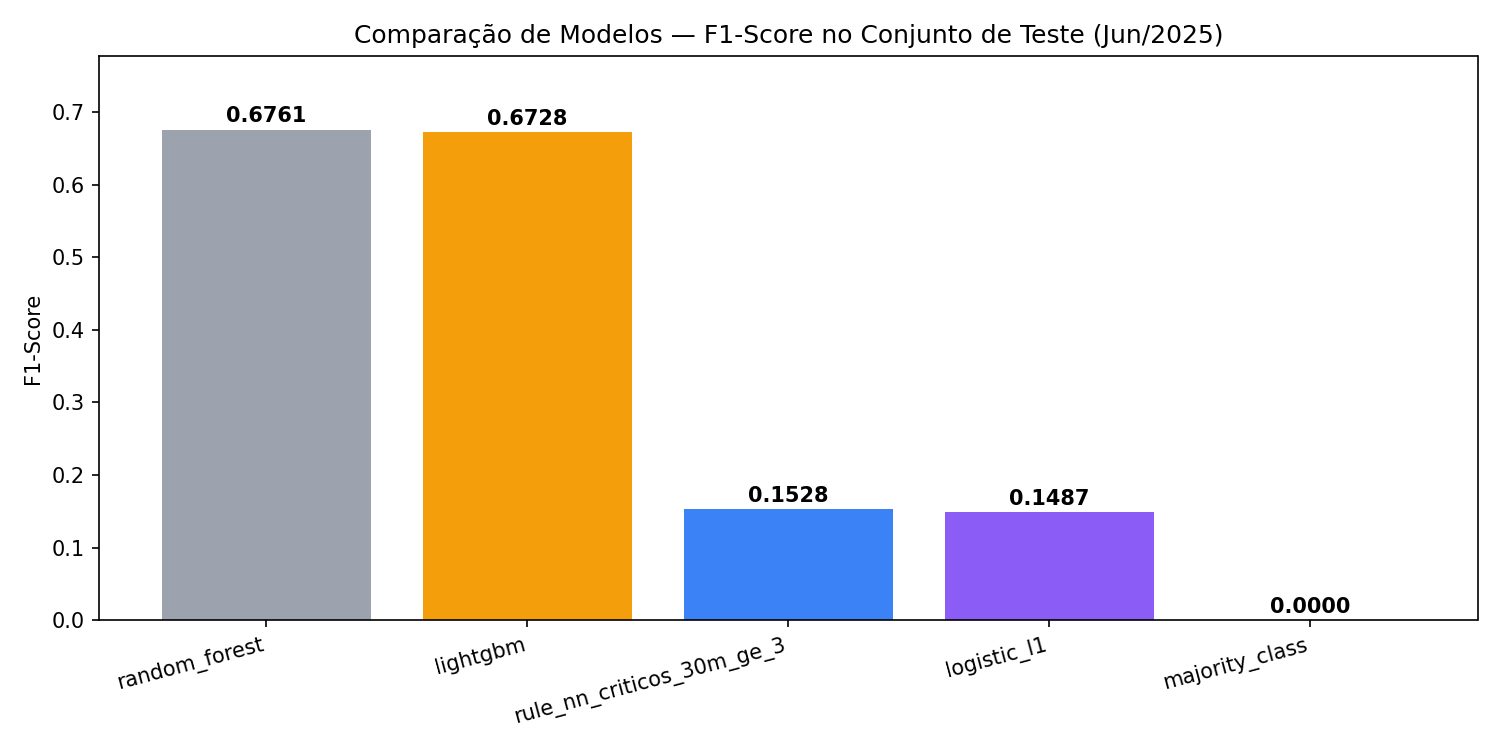

In [3]:
display(Image(filename=str(figures_dir / 'comparison_f1_bar.png')))

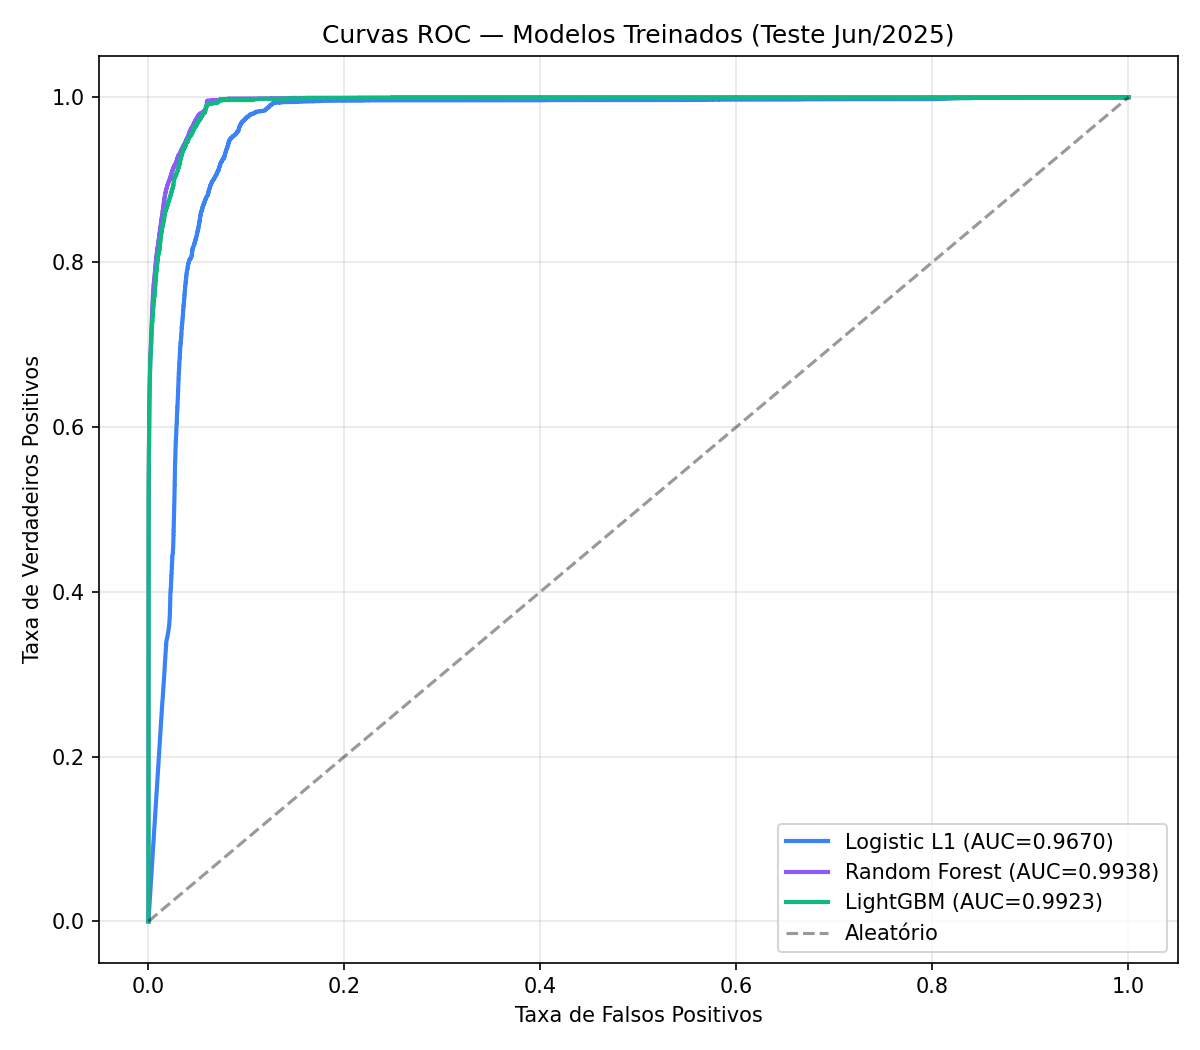

In [4]:
display(Image(filename=str(figures_dir / 'comparison_roc_curves.png')))

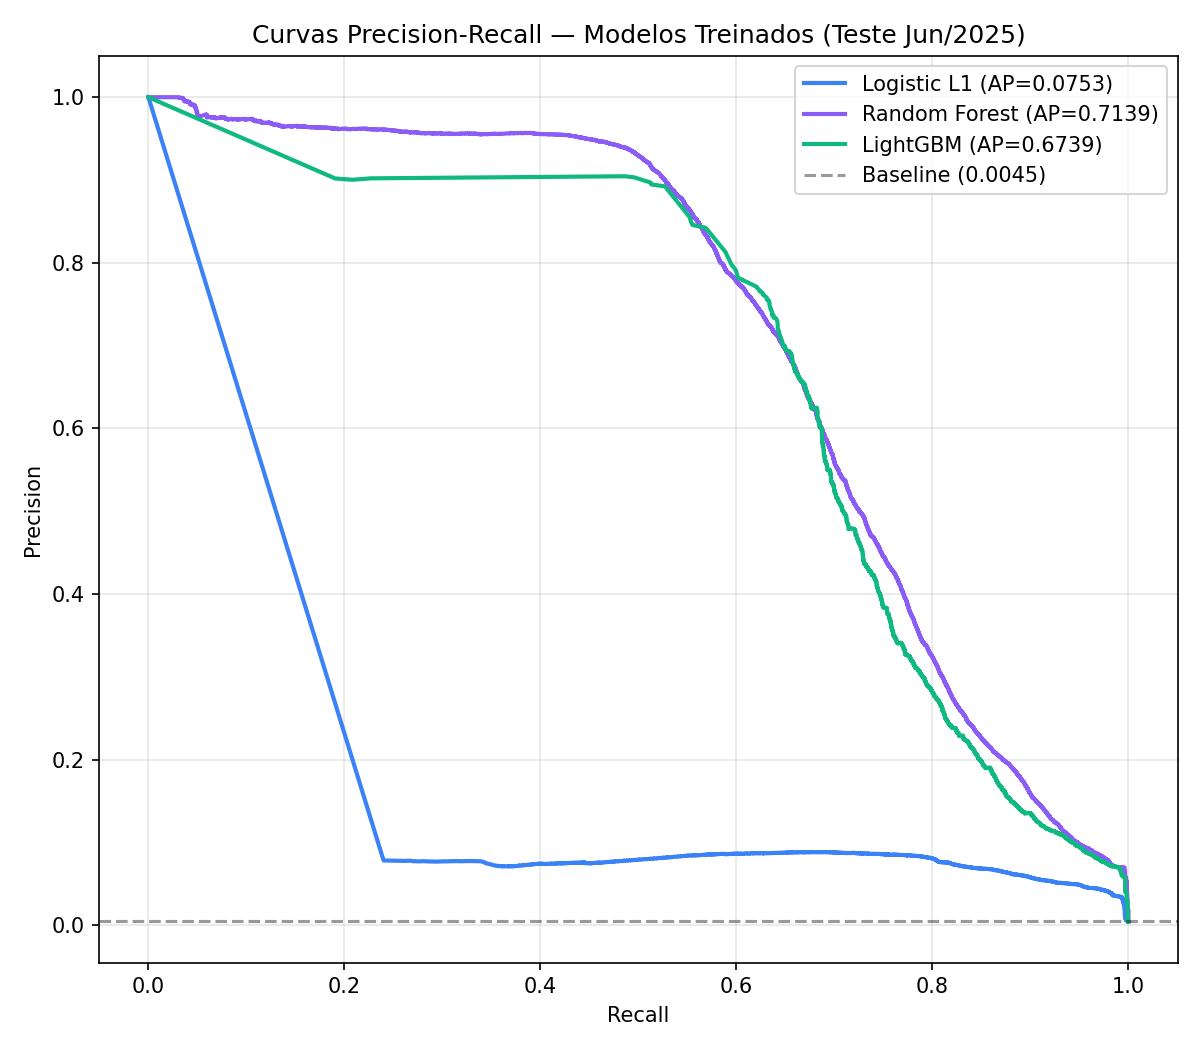

In [5]:
display(Image(filename=str(figures_dir / 'comparison_pr_curves.png')))

## Conclusão Metodológica (CM 4.3)

1. **Hierarquia clara de desempenho:** Random Forest ≈ LightGBM >> Regressão Logística > Regra de negócio > Naive.
2. **Ganho de F1 do ML vs heurística:** 0.6761 vs 0.1528 → **+343%** de melhoria em F1. Em valor absoluto, o ML reduz falsos alarmes em ~7× mantendo recall superior.
3. **Escolha do modelo principal:** mantemos **LightGBM** como modelo de produção pela diferença insignificante de F1 frente ao Random Forest, vantagens em tempo de inferência, suporte a dados esparsos do fingerprint e melhor explicabilidade SHAP.
4. **Random Forest como modelo de fallback / segunda opinião:** mantido para análise de ensemble e detecção de drift futura.
5. **Regressão logística como diagnóstico:** mantida como evidência empírica de que o problema exige modelos não-lineares — a alta ROC-AUC combinada com PR-AUC baixíssimo é a assinatura de um problema mal aproximado por modelo linear.